# K-Means Clustering

**Objective:** group customers into segments using K-Means, without
giving the algorithm any labels - mirroring the customer segmentation
example on slide 64 and the step-by-step centroid animation on
slides 68-69.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

## The Dataset

Unsupervised learning means there is no output/label column (slide
37) - only input features. We simulate 90 customers described by two
features: Annual Income and Spending Score, forming 3 natural but
unlabeled groups.

In [2]:
X, _ = make_blobs(n_samples=90, centers=3, cluster_std=1.1, random_state=42)

customers = pd.DataFrame(X, columns=['Annual_Income', 'Spending_Score'])
# rescale into more realistic ranges
customers['Annual_Income'] = (customers['Annual_Income'] * 12 + 60).round(1)
customers['Spending_Score'] = (customers['Spending_Score'] * 12 + 50).round(1)
customers.head()

,Annual_Income,Spending_Score
0,140.6,76.0
1,23.8,172.1
2,-19.1,-22.2
3,106.4,69.4
4,-38.9,-50.0


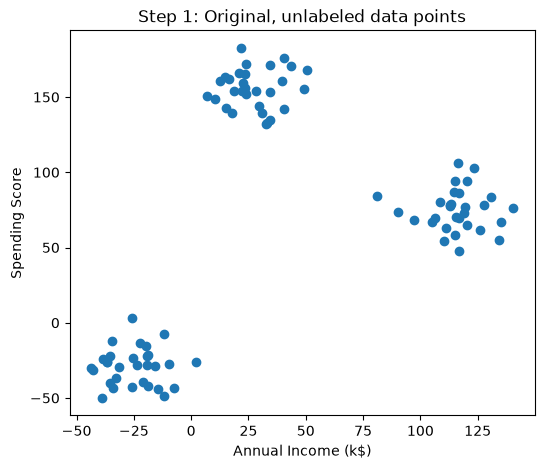

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(customers['Annual_Income'], customers['Spending_Score'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Step 1: Original, unlabeled data points')
plt.show()

Notice there's no color or label yet - just like slide 68's "Step
1. Original data points," we can't tell K-Means how many groups
*should* exist just by looking; we have to choose k.

## Step 1: Choose k with the Elbow Method

`inertia_` is the sum of squared distances from each point to its
assigned centroid - it always goes down as k increases, but the rate
of improvement drops off sharply once k matches the real number of
clusters (the "elbow").

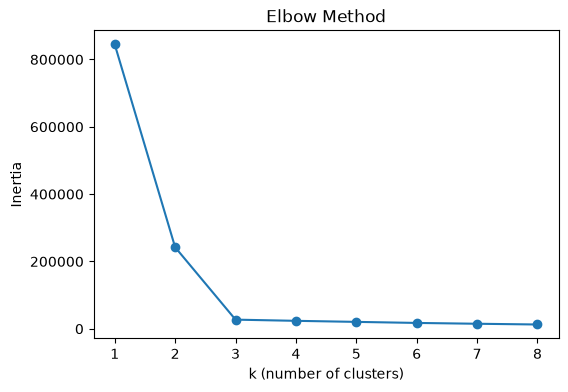

In [4]:
inertias = []
k_values = range(1, 9)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(customers)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## Step 2: Fit K-Means with k=3

The elbow above should bend around k=3, matching how the data was
generated.

In [5]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
customers['Cluster'] = kmeans.fit_predict(customers[['Annual_Income', 'Spending_Score']])
customers.head()

,Annual_Income,Spending_Score,Cluster
0,140.6,76.0,0
1,23.8,172.1,2
2,-19.1,-22.2,1
3,106.4,69.4,0
4,-38.9,-50.0,1


## Step 3: Visualize clusters + centroids

This is the same idea as slide 69's "Step 4" - each centroid (A, B,
C) has settled in the middle of the points assigned to it.

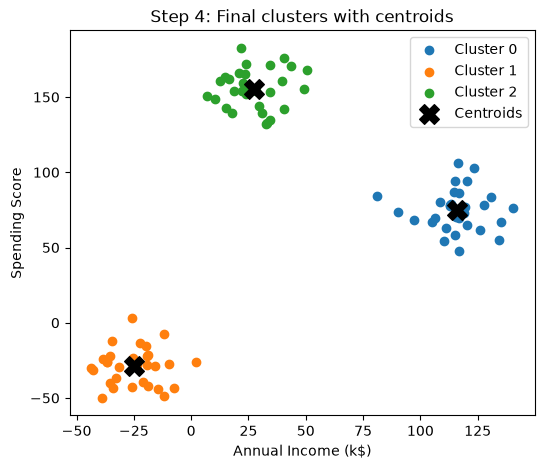

In [6]:
plt.figure(figsize=(6, 5))
for cluster_id, group in customers.groupby('Cluster'):
    plt.scatter(group['Annual_Income'], group['Spending_Score'], label=f'Cluster {cluster_id}')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Step 4: Final clusters with centroids')
plt.legend()
plt.show()

## Step 4: Interpret the clusters

In a real customer-segmentation project (slide 64), this is the step
where each cluster gets a business label, e.g. "high income, low
spending" -> a target for a re-engagement campaign.

In [7]:
customers.groupby('Cluster')[['Annual_Income', 'Spending_Score']].mean().round(1)

,Annual_Income,Spending_Score
Cluster,,
0,115.8,74.9
1,-25.0,-29.0
2,27.2,155.5


## Note: Clustering for Anomaly Detection

Slide 66 shows another use of K-Means: points that end up *far* from
every centroid can be flagged as anomalies (e.g. fraud, faulty
sensors) rather than assigned to a "normal" cluster - the same
centroid-distance idea, used differently.